# 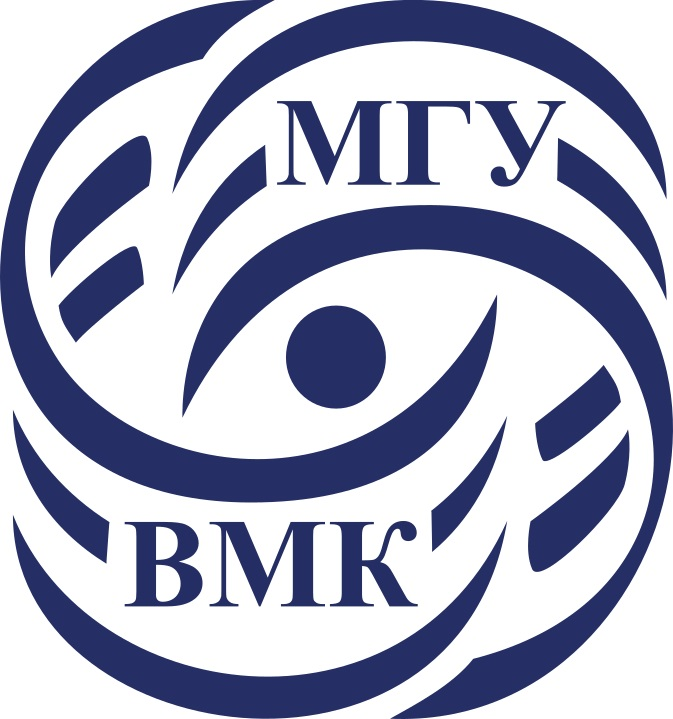

# Машинное обучение. ВМК МГУ

# Практическое задание 2. Knn: классификация и регрессия

## Уровень: <font color='MediumSeaGreen'>**Исследовательский (Research)**</font>

# О формате сдачи

🔷 **<font color='plum'>При решении ноутбука используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

-----------
<font color="white" style="opacity:0.2025"></font>







<font color=DarkOrange>**Примерное время выполнения (execution time/время выполнения, если нажать run all) всех ячеек ноутбука при правильной реализации: 10 минут </font>**

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, **возможно,** нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится


На скачивание файла и установку понадобится не более 5 минут.

<font color='OrangeRed'>**Важно!**</font>

Устанавливать нужные версии нужно каждый раз, когда создается новый рантайм. Например, если вы 2 часа подряд делаете это задание, то подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в понедельник, затем закрыли/выключили ноутбук, то при продолжении в среду, вам нужно будет запустить рантайм заново и следовательно заново установить библиотеки.

<font color='OrangeRed'>**Важно!**</font>
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в [соответствии с гайдом](https://github.com/MSU-ML-COURSE/ML-COURSE-24-25/blob/main/tutorials/%D0%A2%D1%83%D1%82%D0%BE%D1%80%D0%B8%D0%B0%D0%BB%20%D0%BF%D0%BE%20%D1%83%D1%81%D1%82%D0%B0%D0%BD%D0%BE%D0%B2%D0%BA%D0%B5%20%D1%80%D0%B0%D0%B1%D0%BE%D1%87%D0%B5%D0%B3%D0%BE%20%D0%BE%D0%BA%D1%80%D1%83%D0%B6%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B2%20Python%20%D0%B4%D0%BB%D1%8F%20%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%20(2).pdf)

In [1]:
! curl https://raw.githubusercontent.com/MSU-ML-COURSE/ML-COURSE-25-26/refs/heads/master/requirements/requirements.txt -o ./requirements_2025_26_for_colab_small.txt
! pip install -r ./requirements_2025_26_for_colab_small.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   360  100   360    0     0   1021      0 --:--:-- --:--:-- --:--:--  1022


Проверим версию библиотеки:

In [2]:
import catboost
assert(catboost.__version__ == '1.2.8')


<font color='OrangeRed'>**Внимание!**</font> Перед выполнение данного задания рекомендуем сначала погрузиться в [Base] ноутбук по основам sklearn, нормализации и кросс-валидации, так как данные техники и понятия будут активно использоваться в данном ноутбук

Теперь можно приступать к выполнению задания! :)

-----------
<font color="white" style="opacity:0.2025"></font>

# Часть 1. Нормализация признакового пространства

В данном части задания исследуем, как нормализация (скейлинг) данных влияет на разделимость данных

In [3]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [4]:
import numpy as np
import seaborn as sns
import pickle

from matplotlib import pyplot as plt


plt.rcParams["figure.figsize"] = (5,5)

Загрузим файл с данными data.pkl:

In [5]:
import gdown

gdown.download(id='1S1SLhRHrdtfHAy0SxWxfPIXMrenID-ZM')

Downloading...
From: https://drive.google.com/uc?id=1S1SLhRHrdtfHAy0SxWxfPIXMrenID-ZM
To: /home/tepumasuta/devs/university/sem 5/ml/task3/research/data.pkl
100%|██████████| 5.03k/5.03k [00:00<00:00, 4.58MB/s]


'data.pkl'

Загрузим данные в память. В переменной $X$ будут храниться признаковые описания объектов, в переменной $y~-$ метки классов

In [6]:
with open('./data.pkl', 'rb') as file:
    X, y = pickle.load(file)

In [7]:
def plot_data_points(X, labels, xlim, ylim):
    g = sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels)
    g.set(xlim=xlim, ylim=ylim)
    plt.xlabel('x_1')
    plt.ylabel('x_2')
    plt.grid()

Визуализируем наши данные

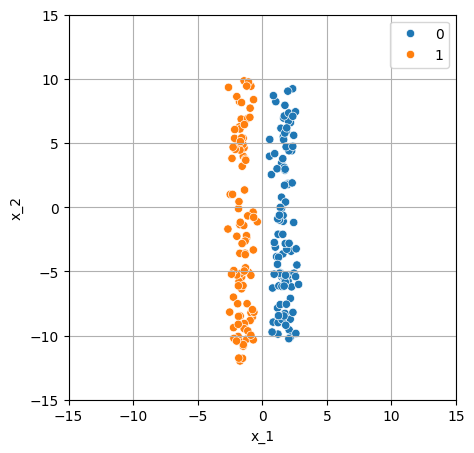

In [8]:
plot_data_points(X, y, xlim=(-15, 15), ylim=(-15, 15))

Как видно, наши данные идеально разделяются прямой $x=0$

Функция $plot\_knn\_bound$ принимает на вход объекты $X$, метки классов $y$, метод нормализации признаков $scaler$, число соседей $n\_neighbors$ и границы рисунка $xlim$, $ylim$. Функция обучает $KNN$ классификатор с числом соседей $n\_neighbors$ и визуализирует разделяющую поверхность для классов, полученную с помощью обученного $KNN$ классификатора.

* Если вы не можете различить _выбранные нами цвета_, то измените список цветов в переменных cmap_light и cmap_bold. Актуальный список возможных цветов находится [здесь](https://matplotlib.org/stable/tutorials/colors/colormaps.html)

In [9]:
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets

def plot_knn_bound(X, y, scaler=None, n_neighbors=10, xlim=(-15, 15), ylim=(-20, 20)):
    # step size in the mesh
    h = 0.05

    # Create color maps
    cmap_light = ListedColormap(['C0', 'orange', 'cyan', 'green'][:np.unique(y).shape[0]])
    cmap_bold = ['C0', 'orange', 'c', 'darkgreen'][:np.unique(y).shape[0]]

    x_min, x_max = xlim
    y_min, y_max = ylim
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    X_scaled = X # if scaler is None
    if scaler is not None:
        grid = scaler.transform(grid)
        X_scaled = scaler.transform(X)

    # we create an instance of Neighbours Classifier and fit the data.
    clf = neighbors.KNeighborsClassifier(n_neighbors, algorithm='brute')
    clf.fit(X_scaled, y)

    Z = clf.predict(grid)

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    # Plot also the training points
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y,
                    palette=cmap_bold, alpha=1.0, edgecolor="black")
    plt.xlabel('x_1')
    plt.ylabel('x_2')
    plt.title('Разделющие поверхности алгоритма {}-NN'.format(n_neighbors))
    plt.grid()
    plt.show()

Нарисуем разделющие поверхности $1$-$NN$ и $10$-$NN$

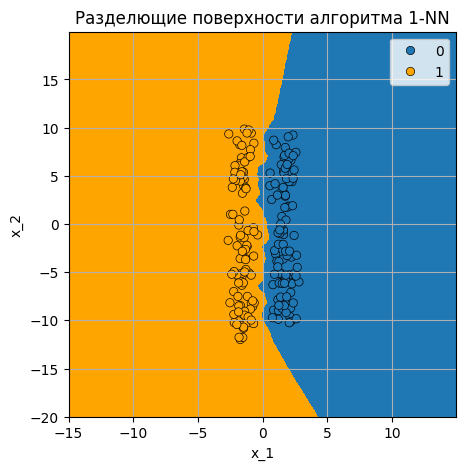

In [10]:
plot_knn_bound(X, y, n_neighbors=1)

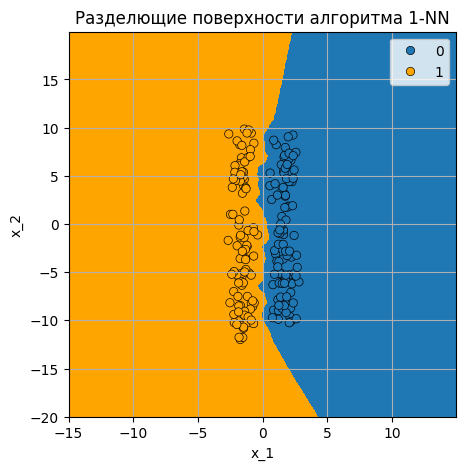

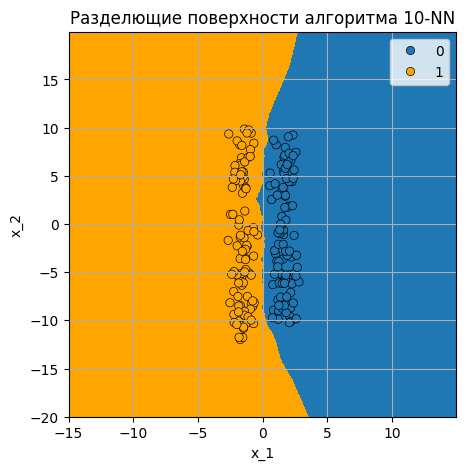

In [11]:
plot_knn_bound(X, y, n_neighbors=1)
plot_knn_bound(X, y, n_neighbors=10)

## <font color='DarkOrange'>**Задание 1.1 (кросс-проверка, 1,5 балла)**</font>

 Объясните, почему наблюдается сильное отклоенние разделяющей поверхности от прямой $x_1=0$ при значениях $x_2 < -10$ и $x_2 > 10$. Дайте <font color='OrangeRed'>**строгое математическое обоснование**</font> наблюдаемого явления, показывающее, что в Евклидовом пространстве данная проблема решается нормализацией (скейлингом) признаков.

<font color='MediumOrchid'>**Ваше обоснование тут, можно использовать LaTeX:**</font>

Без нормализации, рассмотрим крайние точки сверху, при NN=1:
$$\mathbf{A}=(x-x_1+\epsilon_1,y), \mathbf{B}=(x+x_1+\epsilon_2,z)$$
где $\epsilon_1, \epsilon_1$ &mdash; шум

Тогда для точки $\mathbf{X}=(a,b)$, где $b>10$, т.е. $b>y, b>z$, расстояния до точек $\mathbf{A}$ и $\mathbf{B}$:
$$\left||\mathbf{X}-\mathbf{A}|\right| = (a-x+x_1-\epsilon_1)^2+(b-y)^2$$
$$\left||\mathbf{X}-\mathbf{B}|\right| = (a-x-x_1-\epsilon_2)^2+(b-z)^2$$
Разделяющая кривая:
$$\left||\mathbf{X}-\mathbf{A}|\right| = \left||\mathbf{X}-\mathbf{B}|\right|$$
$$(a-x+x_1-\epsilon_1)^2+(b-y)^2 = (a-x-x_1-\epsilon_2)^2+(b-z)^2$$
$$(a-x+x_1)^2-2\epsilon_1(a-x+x_1)+\epsilon_1^2+(b-y)^2 = (a-x-x_1)^2-2(a-x-x_1)\epsilon_2+\epsilon_2^2+(b-z)^2$$
$$2(a-x)x_1-2\epsilon_1(a-x+x_1)+\epsilon_1^2+b^2-2by+y^2 = -2(a-x)x_1-2(a-x-x_1)\epsilon_2+\epsilon_2^2+b^2-2bz+z^2$$
$$4(a-x)x_1-2(\epsilon_1-\epsilon_2)(a-x+x_1)+\epsilon_1^2-\epsilon_2^2-2b(y-z)+y^2-z^2 = 0$$
Без учёта нормализации погрешность эпсилонов много меньше по масштабу, чем разность/сумма y и z:
$$4(a-x)x_1-2b(y-z)+y^2-z^2 = 0$$
$$a-x = \frac{b(y-z)}{2x_1}-\frac{(y-z)(y+z)}{4x_1}$$
Порядок маленькости $y-z=\delta$:
$$a = x+\delta(\frac{b}{2x_1}-\frac{y+z}{4x_1})$$
$$a = x+\delta(\frac{b-y+b-z}{4x_1})$$
И так как $b>y$ и $b>z$, $a =$ чему-то положительному, зависящему линейно от b и это не равно 0 примерно. То есть это прямая, причём далеко не вертикальная

Если нормировать, то бишь, поделить расстояния на дисперсию и вычесть математическое ожидание (равное 0):
$$\left||\mathbf{X}-\mathbf{A}|\right| = \frac{(a+x_1-\epsilon_1)^2}{\sigma_1^2}+\frac{(b-y)^2}{\sigma_2^2}$$
$$\left||\mathbf{X}-\mathbf{B}|\right| = \frac{(a-x_1-\epsilon_2)^2}{\sigma_1^2}+\frac{(b-z)^2}{\sigma_2^2}$$
Тогда порядки размерности сохранятся и получится что-то вроде:
$$4(a-x)x_1-2\epsilon'(a-x+x_1)+0-2b\epsilon'+\epsilon'(y+z) = 0$$
$$(a-x)x_1 = \epsilon' \cdot(...)$$
$$a-x \approx 0$$
$$a \approx x$$
Это уравнение вертикальной прямой $ac_1+bc_2+c_3=0$ при $c_1 = 1, c_2 = 0, c_3 = -x$

До этого получалось уравнение $a = \delta bc_2+\delta c_3 + x + \gamma\cdot(...)$ и $\delta$ &mdash; размах по $x_2$ доминировал $\gamma$ &mdash; размах по $x_1$

После нормировки $\frac{\delta}{\sigma_1^2}=\frac{\gamma}{\sigma_2^2}=\epsilon'$

---

## <font color='DarkOrange'>**Задание 1.2 (кросс-проверка, 2 балла)**</font>


 Пусть дано произвольное число точек на плоскости. Представим, что каждая точка - это отдельный класс. Пусть на данной выборке был обучен $1-NN$ классификатор. Чем с геометрической точки зрения являются разделяющие поверхности этого классификатора? Требуется <font color='OrangeRed'>**математически строго, однозначно и с полным обоснованием**</font> определить геометрическое место точек разделяющих поверхностей.

В качестве примера ниже представлена визуализация для четырех точек

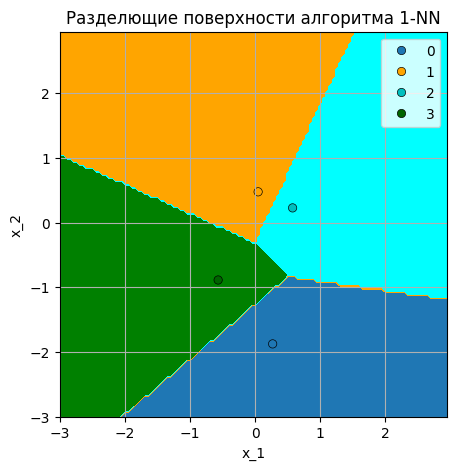

In [12]:
X = np.random.randn(4, 2)
y = np.arange(4)
plot_knn_bound(X, y, n_neighbors=1, xlim=(-3, 3), ylim=(-3, 3))

<font color='MediumOrchid'>**Ваше обоснование тут, можно использовать LaTeX:**</font>

Рассмотрим обучающую выборку, состоящую из n точек на плоскости $\mathbb{R}^2$, где каждая точка $\mathbf{p}_i = (p_{i,1}, p_{i,2})$ для $i = 1, \dots, n$ представляет отдельный класс $c_i$. Пусть обучающая выборка определена как $\mathcal{D} = \{(\mathbf{p}_i, c_i)\}_{i=1}^n$

Обучим классификатор 1-NN на этой выборке. Для произвольной тестовой точки $\mathbf{x} \in \mathbb{R}^2$ предсказание 1-NN будет следующим:

$\hat{y}(\mathbf{x}) = \argmin_{c_j} \| \mathbf{x} - \mathbf{p}_j \|$,

где $\| \cdot \|$ &mdash; евклидова норма. Класс каждой точки $\mathbf{p}_i$ — уникальный, так что ближайшая обучающая точка определяет класс без пересечений за исключением равенства расстояний

Пространство $\mathbb{R}^2$ разделено на области $\mathcal{V}_i$, где для всех $\mathbf{x} \in \mathcal{V}_i$ ближайшая точка &mdash; $\mathbf{p}_i$:

$\mathcal{V}_i = \{ \mathbf{x} \in \mathbb{R}^2 \mid \forall j \neq i, \quad \| \mathbf{x} - \mathbf{p}_i \| \leq \| \mathbf{x} - \mathbf{p}_j \| \}$

Области $\{\mathcal{V}i\}_{i=1}^n$ образуют диаграмму Вороного (Voronoi diagram) для точек $\{\mathbf{p}_i\}$

Разделяющие поверхности &mdash; это границы между этими областями, то есть множества границ $\partial \mathcal{V}_i = \bigcup_{\substack{j \neq i}} (\mathcal{V}_i \cap \mathcal{V}_j)$, где $\partial$ — топологическая граница

Геометрически, каждая граница между $\mathcal{V}_i$ и $\mathcal{V}_j$ (для некоторых $i \neq j$) &mdash; это решетка в точном смысле 1-NN &mdash; является перпендикулярной биссектрисой отрезка, соединяющего $\mathbf{p}_i$ и $\mathbf{p}_j$

То бишь у нас только прямые, лучи и отрезки 

Ничего больше не будет т.к., рассмотрим точку вблизи двух каких-то фиксированных точек, так что остальные точки не будут влиять на нее, при малых отклонениях от исходного положения. $\mathbf{p}_i, \mathbf{p}_j$ - фиксированные точки. Найдем разделяющую поверхность между ними: $\{\mathbf{x}: \rho(\mathbf{x}, \mathbf{p}_i)=\rho(\mathbf{x}, \mathbf{p}_j)\}$:
$$\rho(\mathbf{x}, \mathbf{p}_i)=\rho(\mathbf{x}, \mathbf{p}_j)$$
$$\sum_{k=1}^2 (x_k - p_{ik})^2 = \sum_{k=1}^2 (x_k - p_{jk})^2 $$
$$\sum_{k=1}^2 \left(x_k^2 - 2x_kp_{ik} + p_{ik}^2\right) = \sum_{k=1}^2 \left( x_k^2 - 2x_kp_{jk} + p_{jk}^2 \right)$$
$$\sum_{k=1}^2 \left(- 2x_kp_{ik} + 2x_kp_{jk} \right) = \sum_{k=1}^2 \left(- p_{ik}^2  + p_{jk}^2 \right)$$
$$ -2x_1p_{i1} + 2x_1p_{j1} - 2x_2p_{i2} + 2x_2p_{j2} = -p_{i1}^2  + p_{j1}^2 - p_{i2}^2  + p_{j2}^2$$
$$ 2(-p_{i1} + p_{j1})x_1 + 2(-p_{i2} + p_{j2})x_2 + p_{i1}^2  - p_{j1}^2 + p_{i2}^2 - p_{j2}^2 = 0$$
$$ (-p_{i1} + p_{j1})x_1 + (-p_{i2} + p_{j2})x_2 + \frac{p_{i1}^2  - p_{j1}^2 + p_{i2}^2 - p_{j2}^2}{2} = 0$$

Т.к.  $\mathbf{p}_i \neq \mathbf{p}_j$, одновременно $(-p_{i1} + p_{j1})$ и $(-p_{i2} + p_{j2})$ в ноль не обращаются, следовательно система невырождена и тогда это уравнение прямой. Каждая такая прямая либо продлится до бесконечности, либо дойдёт до точки, где более двух точек имеют однаковое расстояние, тогда при отклонении от точки равенства у нас все точки кроме двух станут более далёкими (т.к. одинаковое расстояние до 3-х точек уже уникально определяет точку в пространстве как пересечение трёх окружностей) и получится прямая с другим наклоном


# Часть 2. Кросс-валидация

Чтобы закрепить понимание устройства кросс-валидации предлагаем вам запрограммировать данный метод самостоятельно

## <font color='DarkOrange'>**Задание 2.1 (unit-tests, 3 балла)**</font>

 В модуле `cross_val.py` реализуйте функции

* $kfold\_split$, которая реализует генерацию индексов обучающей и валидационной выборок для кросс-валидации
* $knn\_cv\_score$, которая реализует кросс-валидацию для $KNN-$модели
   
Примеры запусков функций можно увидеть в открытых тестах.

----

# Часть 3. Работа с текстовыми данными

Далее будем решать задачу классификации новостного текста к одному из 20 классов, каждый класс соответствует определенной новостной тематике.

- В качестве метрики качества будем использовать $accuracy\_score$.

<font color='CornflowerBlue'>**Accuracy**</font> - это доля верно классифицированных объектов, среди всех объектов выборки.

In [13]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [14]:
X_train, y_train = fetch_20newsgroups(subset='train', return_X_y=True, random_state=42)
X_test, y_test = fetch_20newsgroups(subset='test', return_X_y=True, random_state=42)

In [15]:
print(X_train[0])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







In [16]:
X_train = np.array(X_train, dtype=object)

In [17]:
X_test = np.array(X_test, dtype=object)

In [18]:
y_train = np.array(y_train)
y_test = np.array(y_test)

Как мы видим, объектами обучающей выборки являются тексты. Сырые текстовые данные не могут служить обучающими примерами для алгоритма $KNN$. Перед использованием $KNN$ текстовые данные переменной длины необходимо отобразить в числовой вектор фиксированной размерности.

Работа с текстовыми данными проходит в несколько этапов.

* <font color='plum'>**Токенизация.**</font> Текстовая строка делится на токены. Как правило, в качестве токенов выступают отдельные слова и знаки препинания.

* <font color='plum'>**Нормализация.**</font> Приведение к нижнему регистру, удаление стоп-слов, удаление пунктуации, удаление редких и частотных слов и т.д.

* <font color='plum'>**Векторизация.**</font> Фиксируется словарь токенов $V$ по **обучающей** выборке. Текст представлется в виде вектора длиной $|V|$, где каждый признак есть функция от частоты встречаемости токена в тексте и в обучающей выборке.

В данном задании будет использовано два вида векторизации.

* Первый, $CountVectorizer$, сопоставляет каждому токену частоту встречаемости этого токена в тексте документа.

*  Второй, $TfidfVectorizer$, сопоставляет каждому токену частоту встречаемости этого токена в тексте документа умноженную на величину обратно пропорциональную частоте встречаемости токена во всех документах **обучающей** выборки. Подробне про $tf-idf$ предлагаем изучить самостоятельно, например, [здесь](https://ru.wikipedia.org/wiki/TF-IDF).

<font color='MediumTurquoise'>**Полезные ссылки**</font>

Более подробно про работу с текстами можно прочитать в [статье](https://habr.com/ru/companies/otus/articles/687796/) на Хабре и в [NLTK Book](https://www.nltk.org/book/).

В `sklearn` все векторизаторы автоматически токенизируют текст и приводят его к нижнему регистру. Параметры $max\_df$ и $min\_df$ позволяют убрать из словаря наиболее частые и наиболее редкие токены. Параметр $stop\_words$ позволяет убрать из словаря стоп-слова (малоинформативные слова для данного языка, например, союзы).

In [19]:
count_vec = CountVectorizer(max_df=0.8, min_df=10, max_features=1000, stop_words='english')
tf_idf = TfidfVectorizer(max_df=0.8, min_df=10, max_features=1000, stop_words='english')

## <font color='DarkOrange'>**Задание 3.1 (кросс-проверка, 0,5 баллa)**</font>

 Найдите оптимальные параметры обучения модели. Осуществлять перебор параметров следует по заданной ниже сетке.

 - Используйте реализованные вами функции $kfold\_split$, $knn\_cv\_score$. В качестве метрики используйте $accuracy\_score$. 3х фолдов для кросс-валидации будет достаточно.

In [20]:
from sklearn.metrics import accuracy_score

parameters = {
    'n_neighbors': [i for i in range(1, 11)],
    'metrics': ['cosine'],
    'weights': ['uniform', 'distance'],
    'normalizers': [(count_vec, 'CountVectorizer'), (tf_idf, 'TfidfVectorizer')]
}

Если вы все сделаете правильно, то запущенная вами кросс-валидация будет работать примерно 7 минут. Дождитесь ее завершения, не закрывайте и не перезагружайте этот colab ноутбук.

In [21]:
from cross_val import kfold_split, knn_cv_score
from sklearn.neighbors import KNeighborsClassifier

In [22]:
stats = knn_cv_score(X_train, y_train, parameters, accuracy_score, kfold_split(X_train.size, 3),  KNeighborsClassifier)
stats # I was stupid enough to not save it the first time

{('CountVectorizer', 1, 'cosine', 'uniform'): np.float64(0.6723527461486092),
 ('CountVectorizer', 1, 'cosine', 'distance'): np.float64(0.6723527461486092),
 ('CountVectorizer', 2, 'cosine', 'uniform'): np.float64(0.6110139762633834),
 ('CountVectorizer', 2, 'cosine', 'distance'): np.float64(0.6725295573491171),
 ('CountVectorizer', 3, 'cosine', 'uniform'): np.float64(0.6176428613409305),
 ('CountVectorizer', 3, 'cosine', 'distance'): np.float64(0.6682874477217672),
 ('CountVectorizer', 4, 'cosine', 'uniform'): np.float64(0.6154331548676768),
 ('CountVectorizer', 4, 'cosine', 'distance'): np.float64(0.66687340336791),
 ('CountVectorizer', 5, 'cosine', 'uniform'): np.float64(0.6185263080537139),
 ('CountVectorizer', 5, 'cosine', 'distance'): np.float64(0.6643980699950198),
 ('CountVectorizer', 6, 'cosine', 'uniform'): np.float64(0.6141066138965495),
 ('CountVectorizer', 6, 'cosine', 'distance'): np.float64(0.659713733175518),
 ('CountVectorizer', 7, 'cosine', 'uniform'): np.float64(0.61

## <font color='DarkOrange'>**Задание 3.2 (кросс-проверка, 0,5 балл)**</font>

 Какой метод предобработки данных в среднем дает наилучший результат? Почему?

In [23]:
import pandas as pd

In [24]:
data = tuple(key + (score,) for key, score in stats.items())
names = ['normalizer', 'n_neighbors', 'metric', 'weight', 'score']
statsdf = pd.DataFrame(data, columns=names)

In [25]:
statsdf.groupby('normalizer')['score'].mean()

normalizer
CountVectorizer    0.638961
TfidfVectorizer    0.662670
Name: score, dtype: float64

<font color='MediumOrchid'>**Ваш ответ тут:**</font>

Tfidf в среднем дает наилучший результат

Поч? &mdash; ну он, в отличие от count-а пытается выявить семантическую связь и глобальную важность слов в тексте, вместо грубого статистического анализа, то бишь подсчёта. Он использует веса TF (term frequency) и IDF (inverse document frequency), что подавляет "шумные" высокочастотные слова, делая вектора более релевантными для семантического сходства

## <font color='DarkOrange'>**Задание 3.3 (кросс-проверка, 1 балл)**</font>

 Начертите график (line plot) зависимости метрики качества от числа соседей. Метрику следует усреднить по всем параметрам, кроме числа соседей. Сделайте выводы о наблюдаемых зависимостях (возможно будет полезным ознакомиться с названиями классов)

In [26]:
averaged_scores = statsdf.groupby('n_neighbors')['score'].mean()

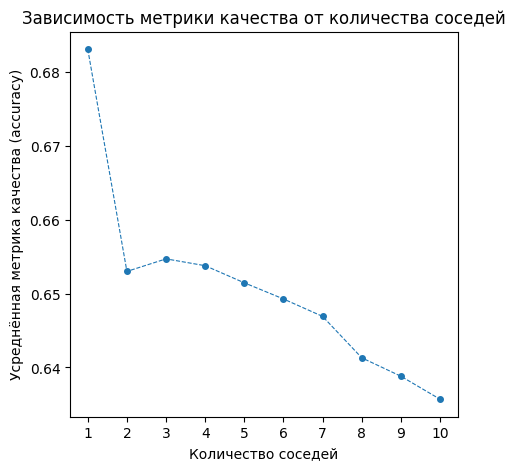

In [27]:
figure, axis = plt.subplots()
plt.title('Зависимость метрики качества от количества соседей')
plt.xlabel('Количество соседей')
plt.ylabel('Усреднённая метрика качества (accuracy)')
plt.plot(averaged_scores, 'o--', lw=0.8, ms=4)
_ = axis.set_xticks(averaged_scores.index)


In [28]:
averaged_scores_count = statsdf[statsdf.normalizer == 'CountVectorizer'].groupby('n_neighbors')['score'].mean()
averaged_scores_tfidf = statsdf[statsdf.normalizer == 'TfidfVectorizer'].groupby('n_neighbors')['score'].mean()

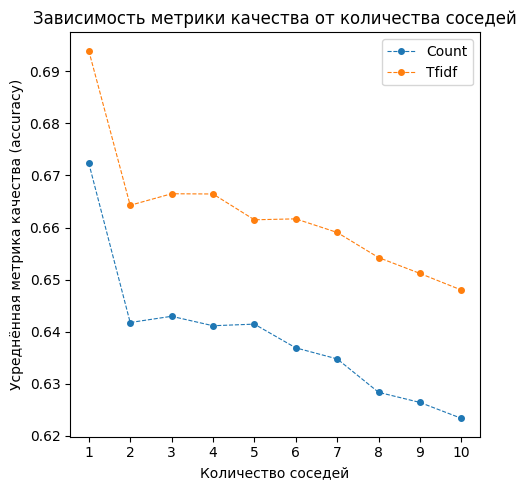

In [29]:
figure, axis = plt.subplots()
plt.title('Зависимость метрики качества от количества соседей')
plt.xlabel('Количество соседей')
plt.ylabel('Усреднённая метрика качества (accuracy)')
plt.plot(averaged_scores_count, 'o--', lw=0.8, ms=4, label='Count')
plt.plot(averaged_scores_tfidf, 'o--', lw=0.8, ms=4, label='Tfidf')
axis.set_xticks(averaged_scores.index)
plt.tight_layout()
plt.legend()
plt.show()


In [30]:
fetch_20newsgroups().target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

<font color='MediumOrchid'>**Ваш ответ тут:**</font>

Точность максимальна при 1 соседе и практически монотонно снижается к 10. Вероятнее всего при меньшем числе соседей модель может хорошо различать уникальные темы, те же религия vs. спорт, но снижение с ростом количества соседей гасит нюансы, делая модели менее жесткими для конкурентных классов, ну или при n=1 модель просто переобучается, ну формально KNN кнчн не обучается, но тип шум заполоняет всё. Или может на близких векторах документов, т.к. есть смежные классы, большое число соседей не позволяет из них выбрать специфичного представителя, то бишь усреднение приводит к ухудшению различия между классами, когда классы семантически близки (но это далеко не факт). Ну а у нас классы семантически пересекаются (например, talk.politics.guns и talk.politics.mideast), поэтому косинусовая метрика подходит для захвата сходства в векторном пространстве текстов в целом, но увеличивает сложность предсказания. То бишь, обобщает оно при большем n всё лучше и лучше, но из-за того, что много тем из одного общего вектора, это негативно сказывается на деталях, то бишь мы может talk.politics.guns и talk.politics.mideast обобщить до политики, и непонятно, как их различить тогда


## <font color='DarkOrange'>**Задание 3.4 (кросс-проверка, 1,5 баллa)**</font>

 Оцените точность вашей лучшей модели на тестовой части датасета. Отличается ли оно от качества, полученного на кросс-валидации? Почему? При ответе на поставленные вопросы вам поможет анализ распределений обучающей и тестовой выборок

In [31]:
from sklearn.pipeline import Pipeline
import numpy as np

In [32]:
statsdf.loc[statsdf.score.idxmax()]

normalizer     TfidfVectorizer
n_neighbors                  1
metric                  cosine
weight                 uniform
score                 0.693918
Name: 20, dtype: object

In [33]:
clf = Pipeline(list({
    'normalizer': tf_idf,
    'classifier': KNeighborsClassifier(
        n_neighbors=10,
        metric='cosine',
        weights='uniform',
    ),
}.items()))

clf.fit(X_train, y_train)


Pipeline(steps=[('normalizer',
                 TfidfVectorizer(max_df=0.8, max_features=1000, min_df=10,
                                 stop_words='english')),
                ('classifier',
                 KNeighborsClassifier(metric='cosine', n_neighbors=10))])

In [34]:
accuracy_score(y_test, clf.predict(X_test))

0.5306691449814126

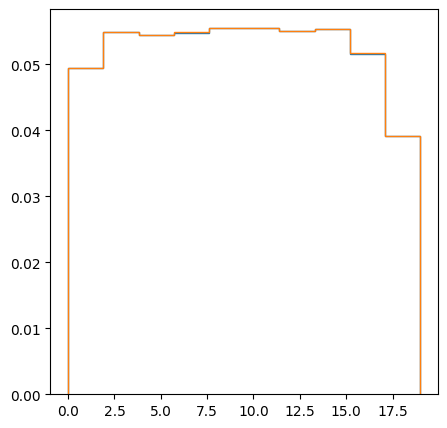

In [35]:
plt.hist(y_train, density=True, histtype='step')
plt.hist(y_test, density=True, histtype='step')
plt.show()

In [36]:
folds_cross = kfold_split(y_train.size, 3)

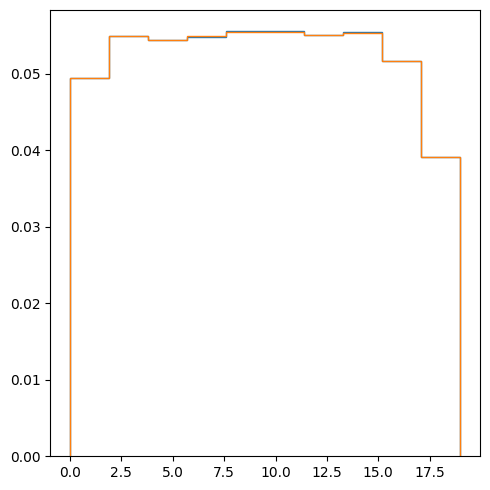

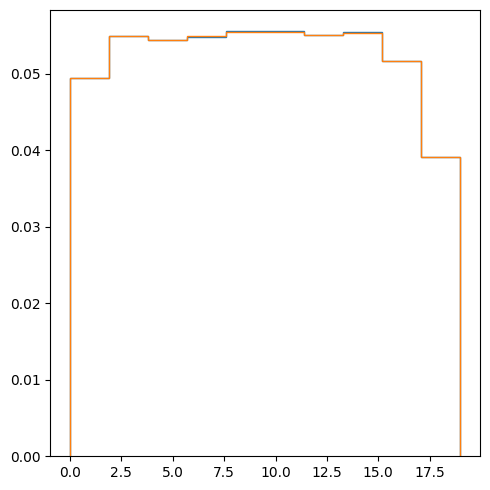

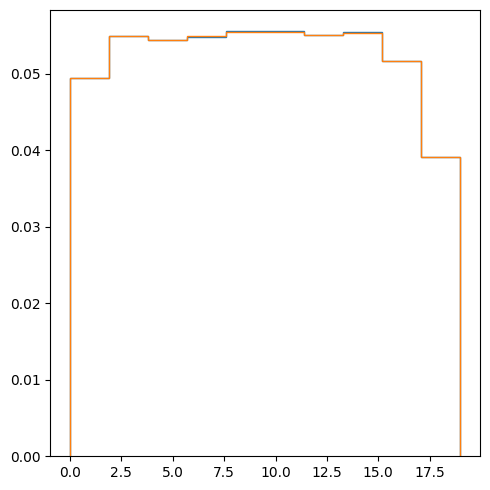

In [37]:
for fold_train, fold_test in folds_cross:
    yn_train = y_train[fold_train]
    yn_test = y_train[fold_test]

    plt.hist(y_train, density=True, histtype='step')
    plt.hist(y_test, density=True, histtype='step')
    plt.tight_layout()
    plt.show()

<font color='MediumOrchid'>**Ваш ответ тут:**</font>

Собственно, как я и предполагал, вероятно модель просто переобучилась в кросс валидация. Ну, формально KNN вообще говоря не обучается, однако при малом числе соседей шум преобладает в выборке и по факту сложность модели слишком велика, то есть мы слишком мало обобщили и поэтому так хорошо прошли кросс валидацию, просто запомнив весь датасет. Ну если быть чуть точнее, вероятно при кросс валидации данных для переобучния данных не хватило, а вот при обучении на полной тестовой выборке &mdash; как раз. А распределение, как мы видим, одинаковое, то бишь, дело совершенно не в нём, вероятнее всего дело в объёме данных. Это моя наилучшая гипотеза

# <font color='MediumSeaGreen'>**Бонус [0,5 балла]**</font>

 Вставьте мем, описывающий ваше состоянии после решения данного ноутбука

Ваша картинка тут

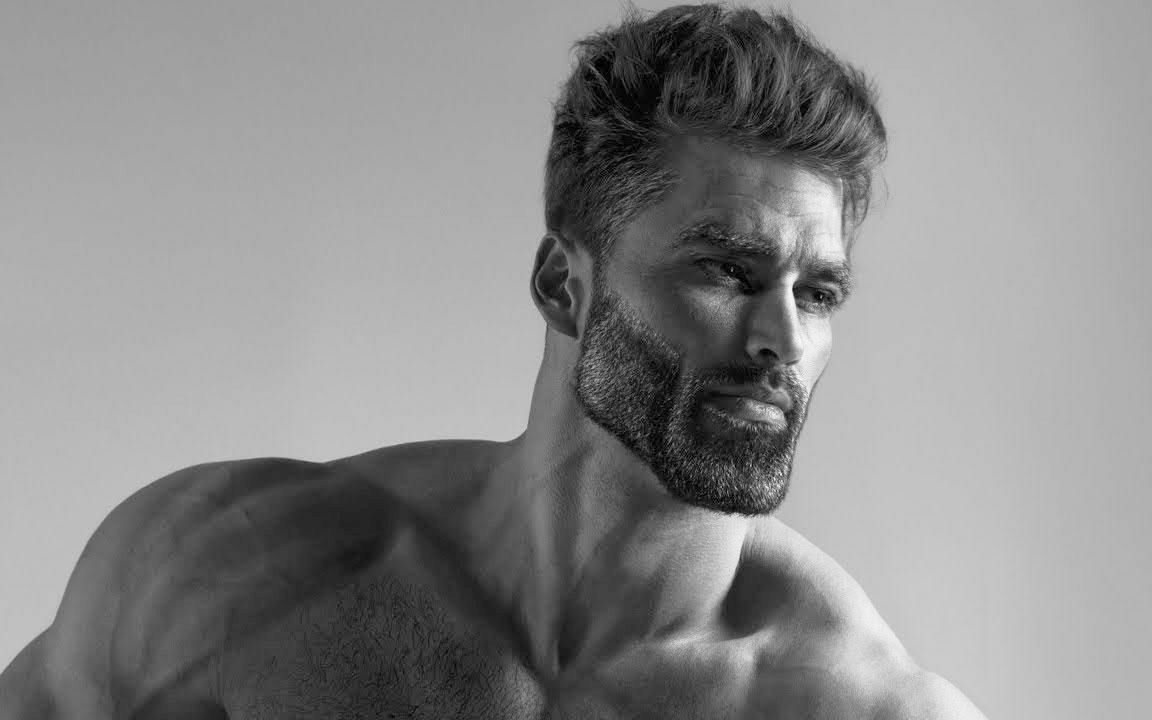